# AUDUSD V. NZDUSD

### IMPORT

In [6]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="statsmodels.tsa.base.tsa_model") # Added to silence the frequency warning
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from descriptive import DESCRIPTIVE

### PARAMS

In [ ]:
# --- Block 1 & 2: Base Windows (Kept as sensible defaults) ---
TRAIN_DAYS = 30
COINT_WINDOW = 300          # Captures the short-term microstructure beta
Z_WINDOW = 100              # Fast rolling mean to fade bid/ask bounces

# --- Block 3: HMM Architecture (Locked from Synthetic Sandbox) ---
K_REGIMES = 2               # Pure binary states
WINSORIZE_STD = 4.0         # UPDATED: Caps real-world kurtosis to prevent HMM panic
SCALING = 10000             # UPDATED: Wide scaling for statsmodels solver stability

# --- Block 4: Execution Logic (Validated on Q4 2023 Data) ---
ENTRY_Z = 2.500             # UPDATED: Wait for extreme deviations
EXIT_Z = -0.500             # UPDATED: Hold past the mean
DANGER_THRESHOLD = 0.550    # UPDATED: Conservative HMM circuit breaker
AR_LIMIT = 0.930            # UPDATED: Strict filter against trending spreads

START_HOUR = 0              # UPDATED: Focus on London open
END_HOUR = 9               # UPDATED: Exit before US close

built 10106 rows

=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=0.77 | B=0.90 bps


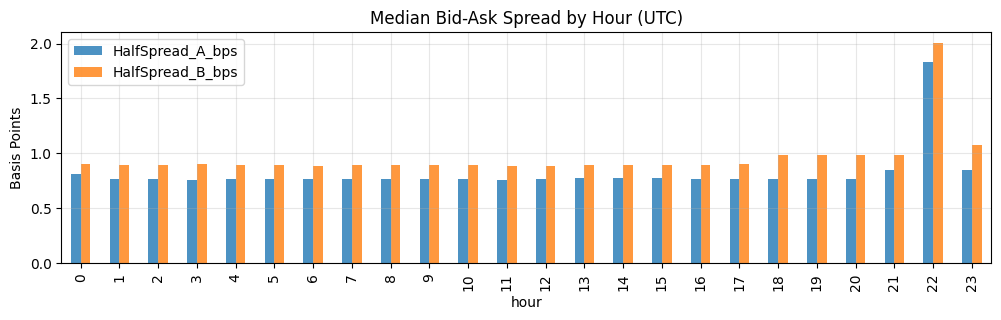


=== RETURN STATISTICS (Log Scale) ===
         Mean (bps)  Vol (bps)      Skew   Kurtosis
AUD/USD   -0.046397   3.802624 -0.522662  10.282642
NZD/USD   -0.037574   3.932509 -0.863125  14.185103

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


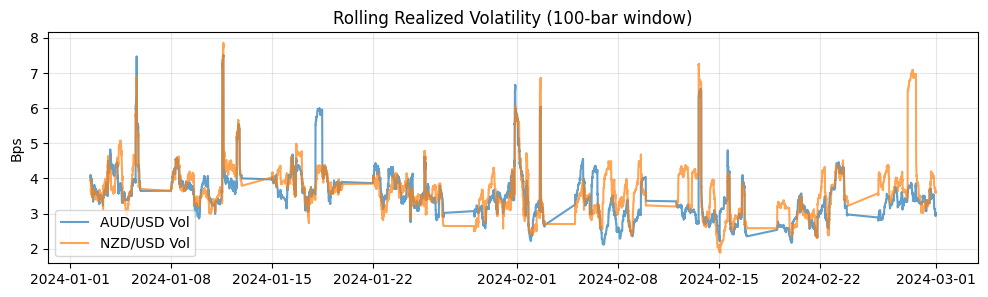

In [8]:
eda_months = ["202401", "202402"]
eda_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in eda_months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in eda_months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in eda_months],
]

# 2. Build 24-hours for the EDA
builder_eda = SPREAD(agg_type='volume', threshold=1000, active_hours=(0, 24)) 
df_raw_eda = builder_eda.build(eda_files)

# 3. Run Descriptive Stats to see the Bar Chart
eda = DESCRIPTIVE(df_raw_eda, "AUD/USD", "NZD/USD")
eda.generate_full_eda()

### DATA

In [9]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/audusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/audusd_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/nzdusd_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

built 37645 rows


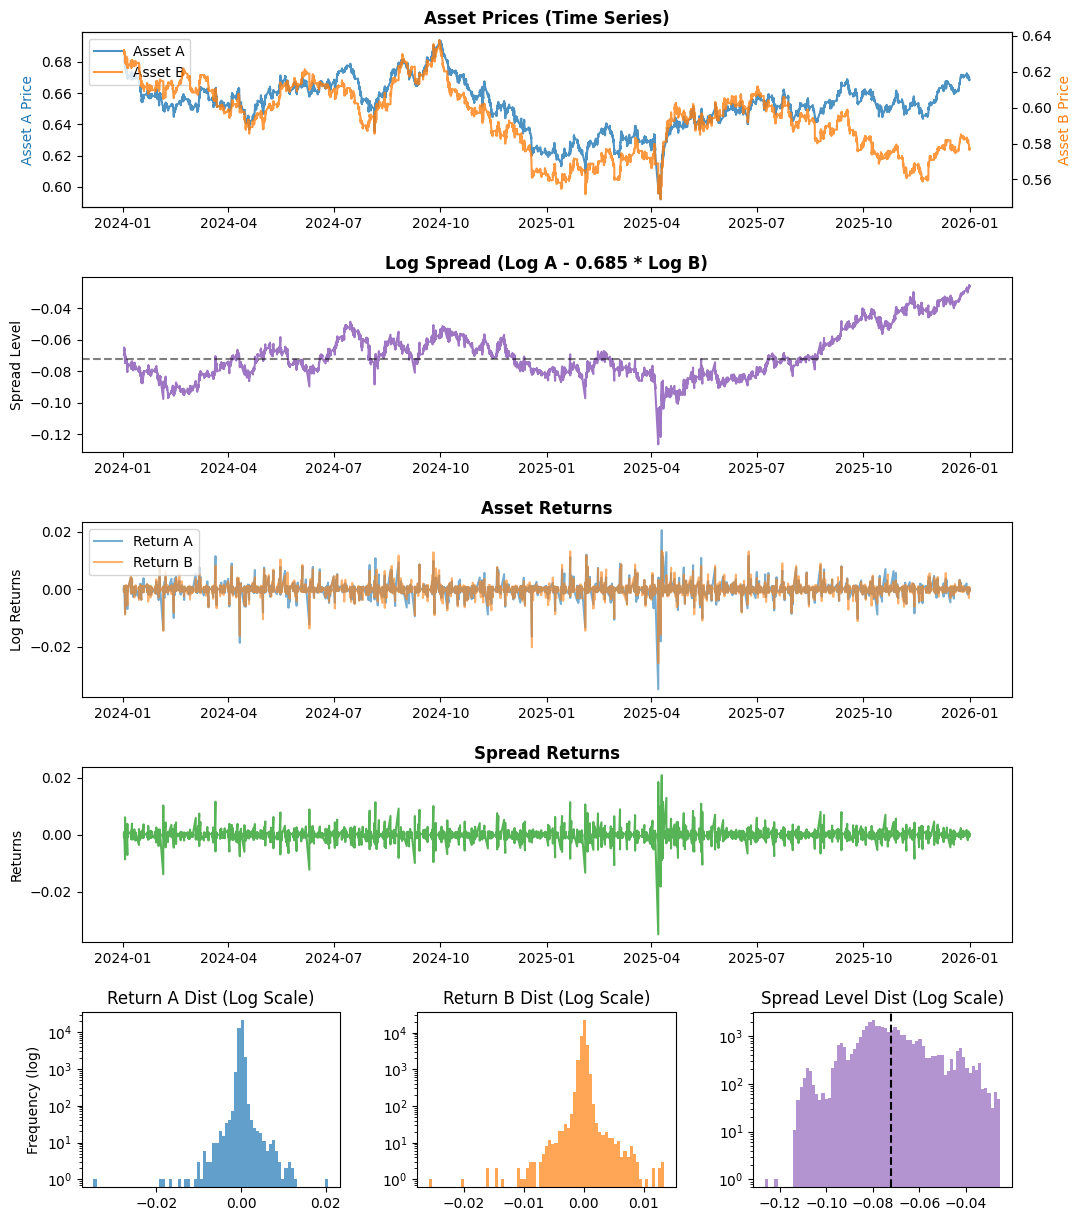

In [ ]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(START_HOUR, END_HOUR)) 
df = builder.build(my_files)
builder.plot_diagnostics()

### DESCRIPTIVE


=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 5:00 to 8:00 UTC
Overall Median Spread: A=0.76 | B=0.89 bps


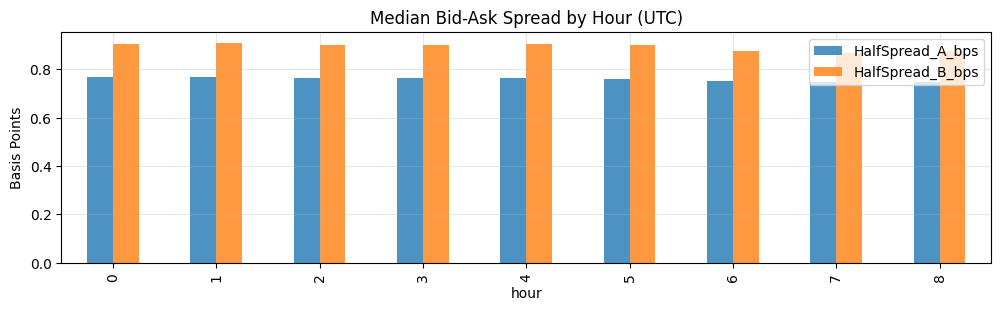


=== RETURN STATISTICS (Log Scale) ===
        Mean (bps)  Vol (bps)     Skew    Kurtosis
AUDUSD   -0.005052   6.891793 -3.57422  293.681324
NZDUSD   -0.024260   6.752048 -2.23924  173.339814

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


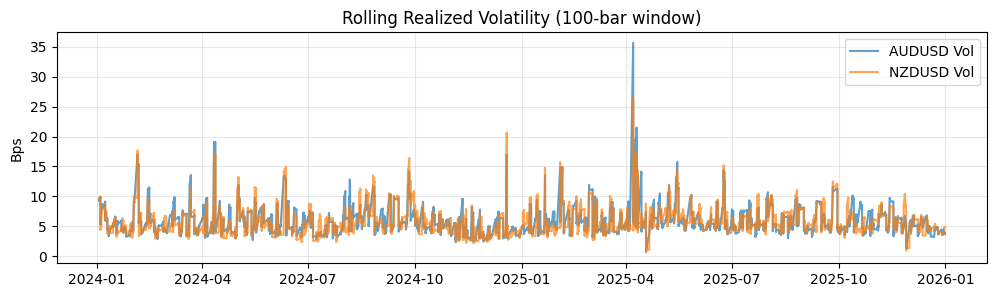

In [11]:
eda = DESCRIPTIVE(df, name_a="AUDUSD", name_b="NZDUSD")
eda.generate_full_eda()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.8683 | half-life=788.5 | β=0.6846

Rolling (2000-bar, step 200, n=179):
  p<0.05: 8.9% | p<0.10: 14.5%
  half-life: 50.9 (IQR 21–88)
  β: 0.7461 ±0.2936 [-0.3448, 1.4143]


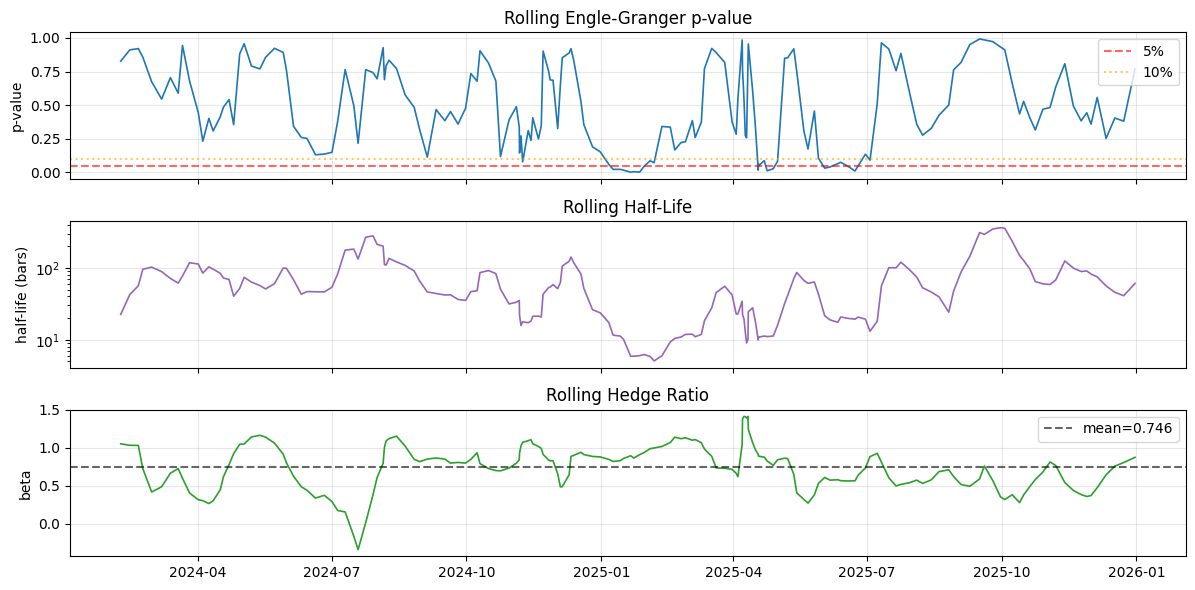

In [12]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=2000, rolling_step=200)

### MORE IMPORTS

In [13]:
import importlib
import engine, backtester, tearsheet
importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### LIVE TRADING

In [14]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df, 
    train_days=TRAIN_DAYS, 
    coint_window=COINT_WINDOW, 
    z_window=Z_WINDOW,
    k_regimes=K_REGIMES,           
    winsorize_std=WINSORIZE_STD,
    scaling=SCALING
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 0.1936 | AR: 0.9507
[2024-02-27] Beta: 0.6451 | AR: 0.9555
[2024-03-12] Beta: 1.2597 | AR: 0.9263
[2024-03-26] Beta: 0.9253 | AR: 0.9624
[2024-04-09] Beta: 1.0929 | AR: 0.9507
[2024-04-23] Beta: 1.1133 | AR: 0.9623
[2024-05-07] Beta: 1.0506 | AR: 0.9317
[2024-05-21] Beta: 0.7130 | AR: 0.9315
[2024-06-04] Beta: 0.9734 | AR: 0.9530
[2024-06-18] Beta: 0.8623 | AR: 0.9394
[2024-07-02] Beta: 0.4863 | AR: 0.9651
[2024-07-16] Beta: -0.2654 | AR: 0.9669
[2024-07-30] Beta: 0.9215 | AR: 0.9702
[2024-08-13] Beta: 1.5651 | AR: 0.9723
[2024-08-27] Beta: 0.6101 | AR: 0.9697
[2024-09-10] Beta: 1.1493 | AR: 0.9612
[2024-09-24] Beta: 1.2414 | AR: 0.9321
[2024-10-08] Beta: 0.6261 | AR: 0.9229
[2024-10-22] Beta: 0.9937 | AR: 0.9258
[2024-11-05] Beta: 1.1597 | AR: 0.9496
[2024-11-19] Beta: 0.7367 | AR: 0.9282
[2024-12-03] Beta: 0.8832 | AR: 0.9476
[2024-12-17] Beta: 1.1029 | AR: 0.9496
[2025-01-02] Beta: 0.8499 | AR: 0.958

### BACKTESTER

In [15]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=ENTRY_Z,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,   
    ar_limit=AR_LIMIT,
    fee_bps=0.5,
    slippage_mode='half_spread'
)

### TEARSHEET


                      QUANTITATIVE STRATEGY TEARSHEET                      
Metric                         | Baseline     | AR           | MS_AR        |
-----------------------------------------------------------------------------

--- FINANCIAL METRICS ---
Total Return (bps)             | 6377.95      | 3139.46      | 643.44       |
Annual Return (bps)            | 3286.80      | 1617.88      | 331.59       |
Annual Volatility (bps)        | 716.26       | 457.05       | 295.43       |
Max Drawdown (bps)             | -229.39      | -130.35      | -139.72      |
Sharpe Ratio                   | 4.59         | 3.54         | 1.12         |
Sortino Ratio                  | 5.33         | 3.15         | 0.63         |
Calmar Ratio                   | 14.33        | 12.41        | 2.37         |
Gross Profit (bps)             | 35945.03     | 14290.10     | 9178.61      |
Gross Loss (bps)               | 29567.08     | 11150.65     | 8535.17      |
Profit Factor                  | 1.22 

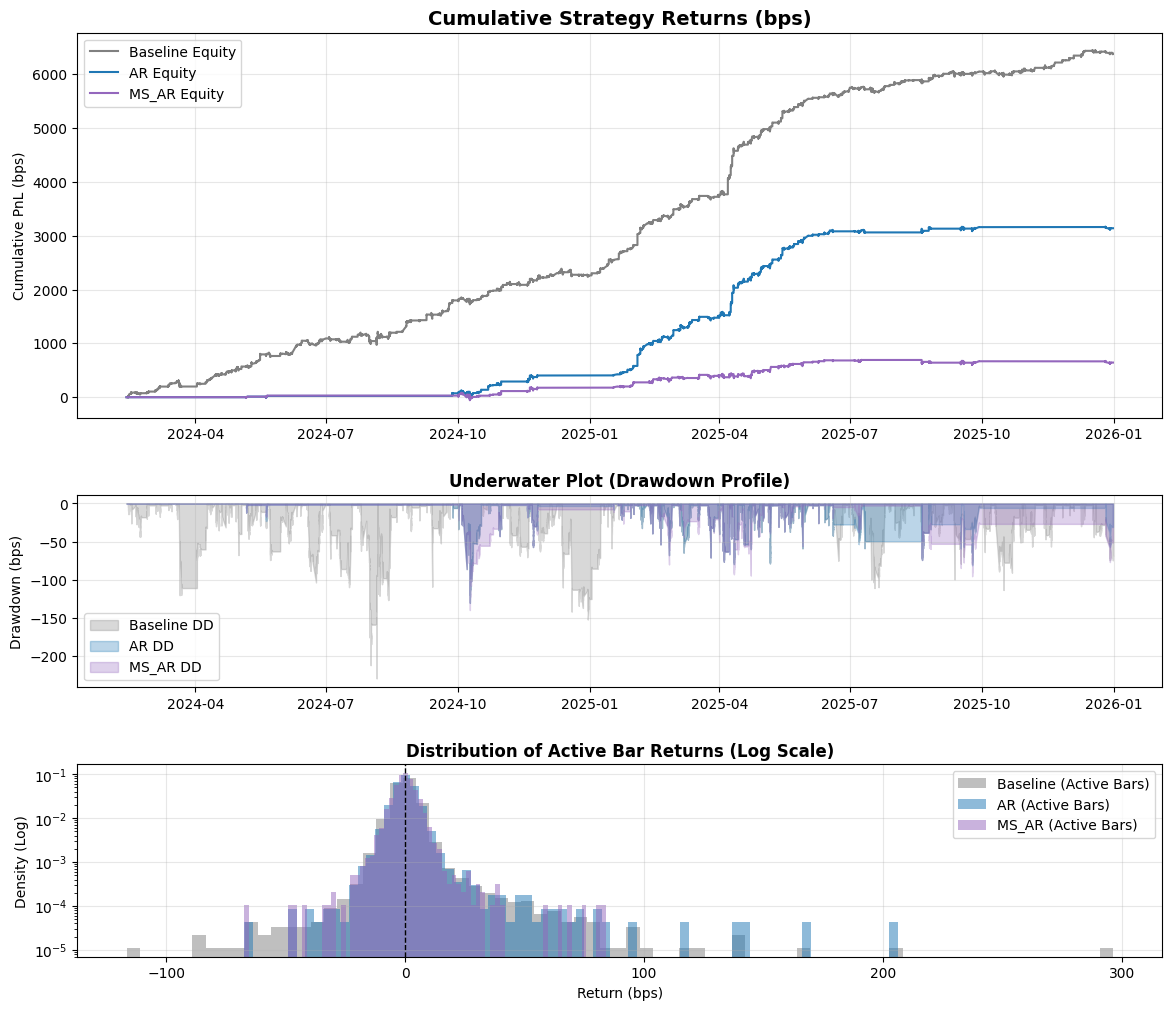

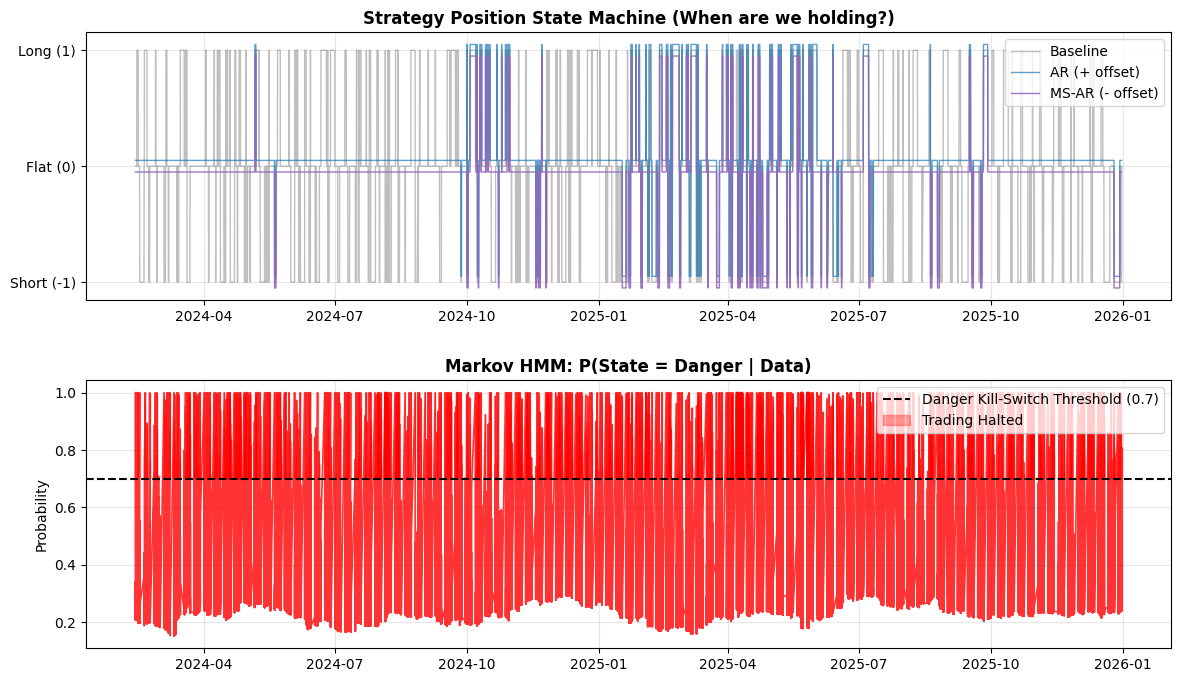

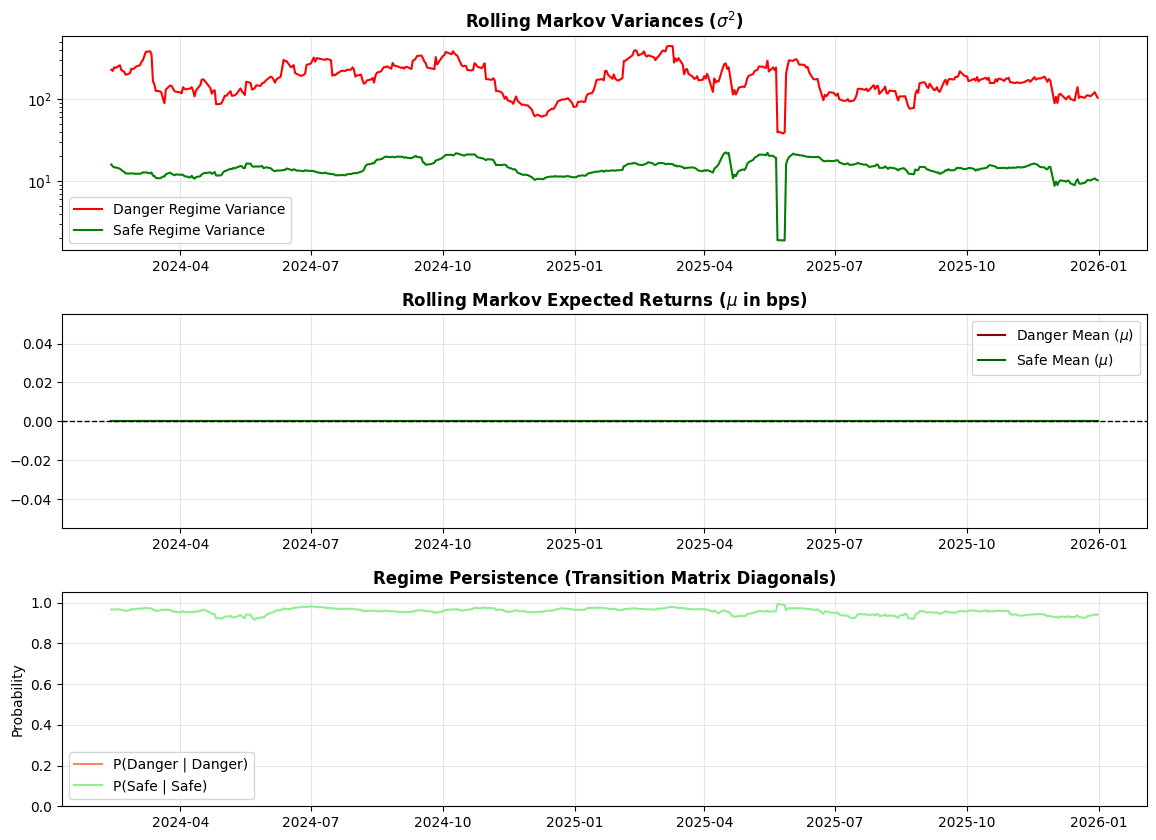

In [16]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()